### Task Level(Advanced):

## Research Question : Retail Sales Performance Analysis 

Which product category generates the highest revenue, and how do customer demographics (age & gender) influence purchasing behavior?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("retail_sales_data.csv")
df

,Order_ID,Date,Customer_ID,Gender,Age,City,Category,Quantity,Unit_Price,Sub_Category,Total_Amount
0,ORD1000,13-04-2023,CUST373,Male,60,Chennai,Camera,1,27353,DSLR,27353
1,ORD1001,15-12-2023,CUST515,Male,52,Bengaluru,Accessories,3,74219,Charger,222657
2,ORD1002,28-09-2023,CUST707,Male,30,Mumbai,Laptop,1,21161,Ultrabook,21161
3,ORD1003,17-04-2023,CUST838,Female,27,Hyderabad,Mobile,1,50993,Smartphone,50993
4,ORD1004,13-03-2023,CUST990,Male,61,Ahmedabad,Camera,4,36995,Mirrorless,147980
...,...,...,...,...,...,...,...,...,...,...,...
1495,ORD2495,03-02-2023,CUST137,Female,25,Bengaluru,Camera,4,44739,DSLR,178956
1496,ORD2496,08-09-2023,CUST871,Male,41,Ahmedabad,Tablet,3,11032,iPad,33096
1497,ORD2497,04-09-2023,CUST287,Female,33,Hyderabad,Tablet,4,79554,Android Tablet,318216
1498,ORD2498,26-09-2023,CUST156,Male,21,Bengaluru,Mobile,3,72512,Smartphone,217536


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      1500 non-null   object
 1   Date          1500 non-null   object
 2   Customer_ID   1500 non-null   object
 3   Gender        1500 non-null   object
 4   Age           1500 non-null   int64 
 5   City          1500 non-null   object
 6   Category      1500 non-null   object
 7   Quantity      1500 non-null   int64 
 8   Unit_Price    1500 non-null   int64 
 9   Sub_Category  1500 non-null   object
 10  Total_Amount  1500 non-null   int64 
dtypes: int64(4), object(7)
memory usage: 129.0+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')    ## Convert Date Column to Datetime

In [6]:
df['Month_Name'] = df['Date'].dt.month_name()                 ## Create Month_name Column

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      1500 non-null   object        
 1   Date          1500 non-null   datetime64[ns]
 2   Customer_ID   1500 non-null   object        
 3   Gender        1500 non-null   object        
 4   Age           1500 non-null   int64         
 5   City          1500 non-null   object        
 6   Category      1500 non-null   object        
 7   Quantity      1500 non-null   int64         
 8   Unit_Price    1500 non-null   int64         
 9   Sub_Category  1500 non-null   object        
 10  Total_Amount  1500 non-null   int64         
 11  Month_Name    1500 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 140.8+ KB


### Revenue by Category

In [31]:
category_sales = df.groupby('Category')['Total_Amount'].sum().reset_index()
category_sales

,Category,Total_Amount
0,Accessories,27293181
1,Camera,32140798
2,Laptop,32635396
3,Mobile,27647520
4,Tablet,30639364


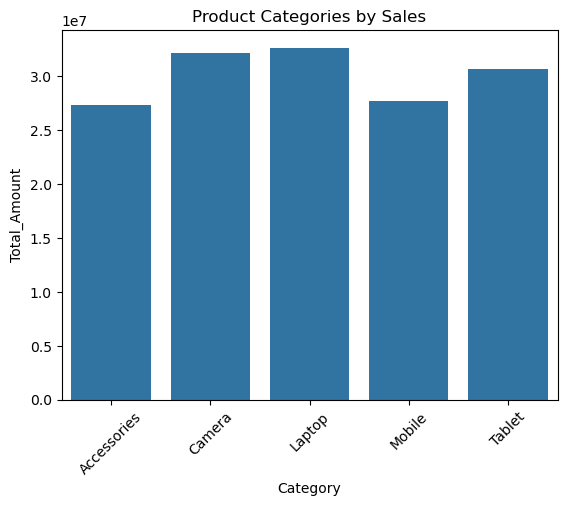

In [32]:
plt.figure()

sns.barplot( data=category_sales, x='Category', y='Total_Amount')
plt.title("Product Categories by Sales")
plt.xticks(rotation=45)
plt.show()

### Revenue by Gender

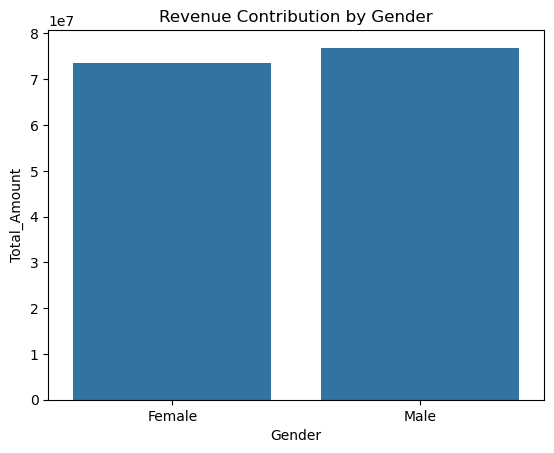

In [9]:
gender_sales = df.groupby('Gender')['Total_Amount'].sum().reset_index()

plt.figure()
sns.barplot(data=gender_sales, x='Gender', y='Total_Amount')
plt.title("Revenue Contribution by Gender")
plt.show()

### Age Groups

C:\Users\admin\AppData\Local\Temp\ipykernel_1996\1902119431.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age_Group')['Total_Amount'].sum().reset_index()


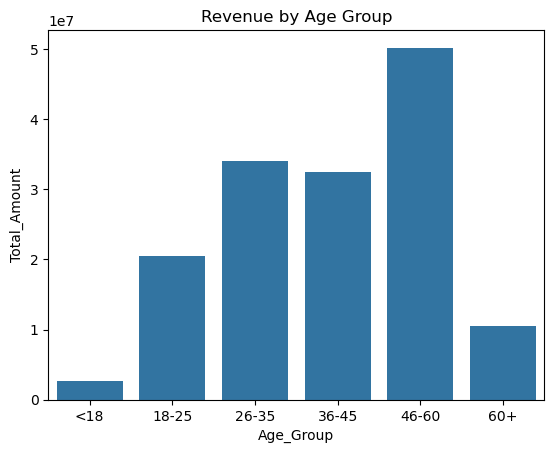

In [10]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age_Group')['Total_Amount'].sum().reset_index()

plt.figure()
sns.barplot(data=age_sales, x='Age_Group', y='Total_Amount')
plt.title("Revenue by Age Group")
plt.show()

### Category Preference by Gender

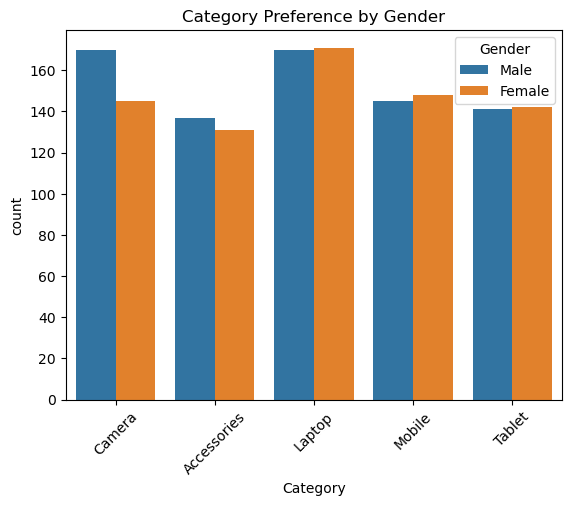

In [11]:
plt.figure()
sns.countplot(data=df, x='Category', hue='Gender')
plt.title("Category Preference by Gender")
plt.xticks(rotation=45)
plt.show()

In [27]:
## gender-wise revenue contribution.
gender_sales = df.groupby('Gender')['Total_Amount'].sum()
gender_sales

Gender
Female    73466725
Male      76889534
Name: Total_Amount, dtype: int64

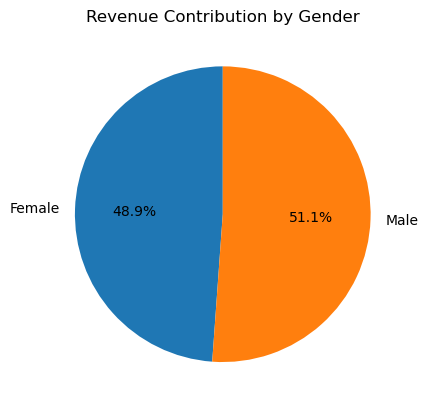

In [28]:
plt.figure()
plt.pie(gender_sales,labels=gender_sales.index,autopct='%1.1f%%',startangle=90)
plt.title("Revenue Contribution by Gender")
plt.show()

### Monthly Sales Trend

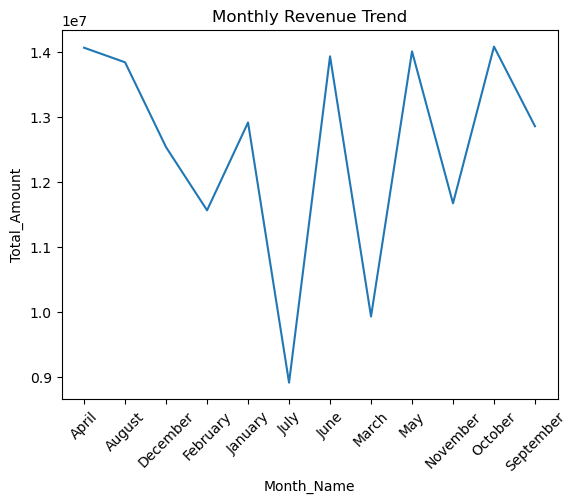

In [12]:
monthly_sales = df.groupby('Month_Name')['Total_Amount'].sum().reset_index()
monthly_sales['Month_Name'] = monthly_sales['Month_Name'].astype(str)

plt.figure()
sns.lineplot(data=monthly_sales, x='Month_Name', y='Total_Amount')
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()


In [24]:
## Calculate City-wise Sales

city_sales = df.groupby('City')['Total_Amount'].sum().reset_index()
city_sales

,City,Total_Amount
0,Ahmedabad,17416918
1,Bengaluru,19424520
2,Chennai,19471821
3,Delhi,18875356
4,Hyderabad,19533578
5,Kolkata,19538649
6,Mumbai,16170151
7,Pune,19925266


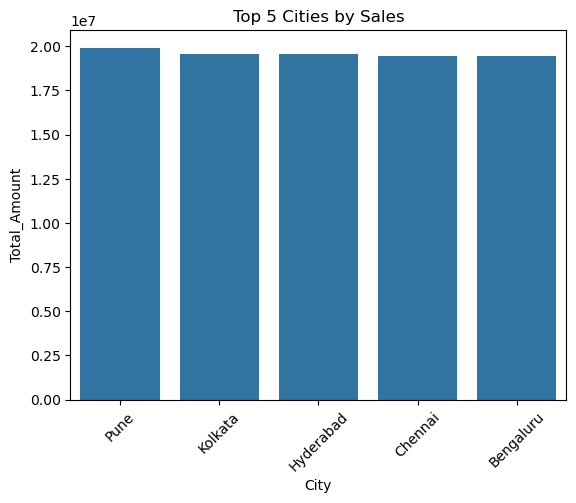

In [30]:
## Visualization – Top 5 Cities
top_cities = df.groupby('City')['Total_Amount'] \
                         .sum() \
                         .sort_values(ascending=False) \
                         .head(5) \
                         .reset_index()

plt.figure()
sns.barplot(data=top_cities,x='City',y='Total_Amount')
plt.title("Top 5 Cities by Sales")
plt.xticks(rotation=45)
plt.show()

####  best-selling product by category is  laptop  follwed by camera. 
#### gender male  contributes more to revenue
#### male prefer more camera and laptops where as female prefer more laptops. Accessories are less prefered by both. 
#### April, may, june and october shows high revenue. 
#### Pune is the top most city with high revenu. 



### Does customer age significantly impact average spending per transaction across different product categories?
#### Calculating average order value
#### Performing correlation analysis
#### Hypothesis testing

In [14]:
## Calculate Average Spending
avg_spending =df.groupby(['Category', 'Age_Group'])['Total_Amount'].mean().reset_index()

avg_spending

C:\Users\admin\AppData\Local\Temp\ipykernel_1996\4050418965.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spending =df.groupby(['Category', 'Age_Group'])['Total_Amount'].mean().reset_index()


,Category,Age_Group,Total_Amount
0,Accessories,<18,88177.300000
1,Accessories,18-25,92458.387097
2,Accessories,26-35,108462.960784
3,Accessories,36-45,116858.700000
4,Accessories,46-60,93988.041237
5,Accessories,60+,99222.368421
6,Camera,<18,79007.400000
7,Camera,18-25,115029.825000
8,Camera,26-35,99519.266667
9,Camera,36-45,95687.136364


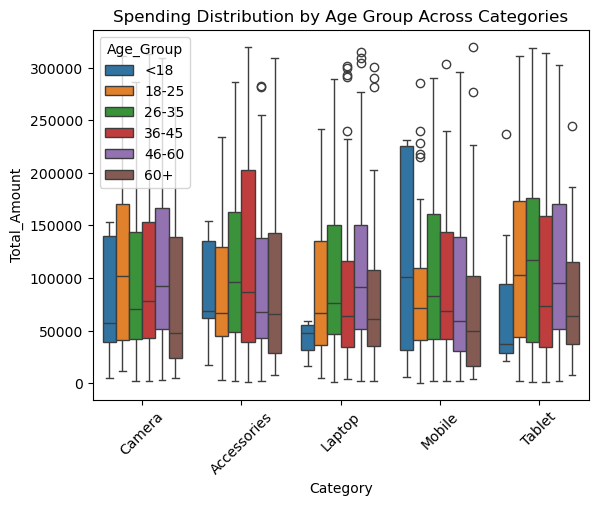

In [15]:
plt.figure()
sns.boxplot(data=df,x='Category',y='Total_Amount',hue='Age_Group')
plt.xticks(rotation=45)
plt.title("Spending Distribution by Age Group Across Categories")
plt.show()

### Statistical Significance (ANOVA Test)

In [33]:
from scipy.stats import f_oneway

for category in df['Category'].unique():
    data = df[df['Category'] == category]
    
    groups = [group['Total_Amount'].values 
              for name, group in data.groupby('Age_Group')]
    
    f_stat, p_value = f_oneway(*groups)
    
    print(f"{category} → p-value: {p_value}")

Camera → p-value: 0.2487965052454601
Accessories → p-value: 0.5220609408507102
Laptop → p-value: 0.17859278450843027
Mobile → p-value: 0.6011023072278802
Tablet → p-value: 0.21557149565053424


C:\Users\admin\AppData\Local\Temp\ipykernel_1996\1704453679.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in data.groupby('Age_Group')]


 p-value > 0.05 which means No significant difference between age and spending.

### Heatmap to visualize correlation between numerical features.

In [21]:
numeric_data =df.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()

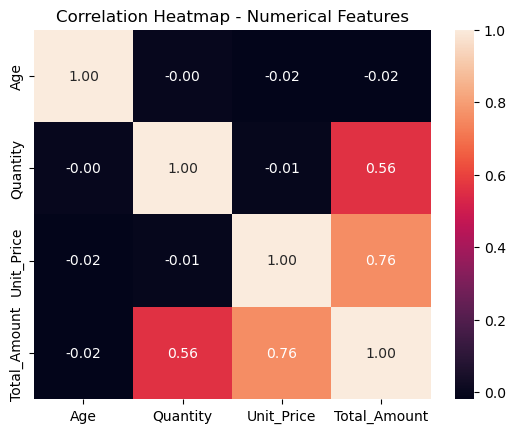

In [22]:
plt.figure()
sns.heatmap(corr_matrix,annot=True,fmt=".2f")
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

In [ ]:
## correlation between Age and Total_Amount 

In [17]:
df[['Age','Total_Amount']].corr()

,Age,Total_Amount
Age,1.000000,-0.019229
Total_Amount,-0.019229,1.000000


No correlation

## Visualize Correlation (Scatter Plot)

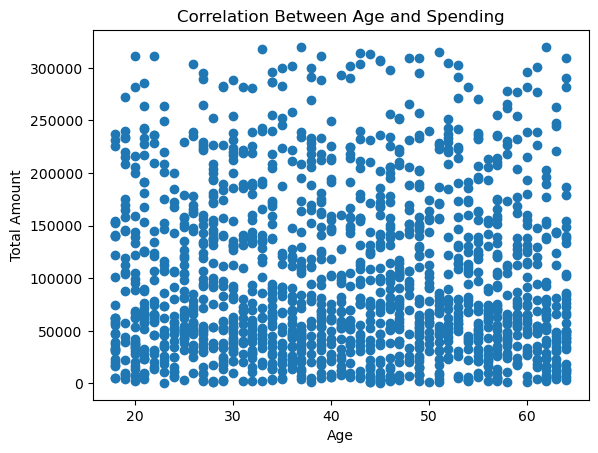

In [18]:
plt.figure()
plt.scatter(df['Age'], df['Total_Amount'])

plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.title("Correlation Between Age and Spending")

plt.show()

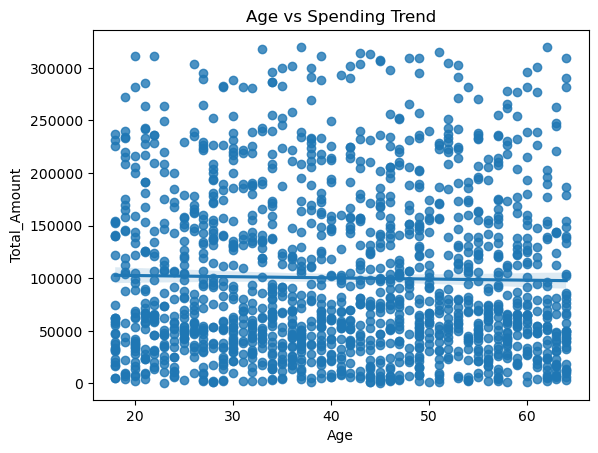

In [19]:
plt.figure()
sns.regplot(data=df, x='Age', y='Total_Amount')
plt.title("Age vs Spending Trend")
plt.show()

In [ ]:
## straight line indicate there is no correlation between age and spending.